# Surface-code memory on IBM Quantum: the logical error rate of a patch

This notebook runs a **quantum memory experiment** with the rotated surface code on a square-lattice IBM chip:
prepare a logical qubit, keep it alive through $R$ rounds of syndrome extraction, read it out, and let a decoder
say whether it survived. The **logical error rate** after $R$ rounds is how error correction is ultimately
judged, which makes it the yardstick for the LR-QAOA benchmark of `benchmark_codes_ibm.ipynb`: both run on
**the same data qubits, ancillas and couplers** of a patch, so a patch can be scored both ways and the scores
compared.

**Safe by default:** nothing is sent to IBM until you set `SUBMIT = True`. Until then the circuits run locally on
Aer's stabilizer simulator, under a Pauli noise model built from the chosen device's calibration (or a uniform
one with `BACKEND_NAME = "noisy_simulator"`, which needs no account). Those results are filed as `<device>_sim`
and flagged `"simulated": true`.

**Requirements**
* `pip install -e ".[ibm,qec]"` from the repository root (Qiskit Runtime, `stim`, `pymatching`), or keep the
  `sys.path` line of the next cell;
* for a real device, an IBM Quantum account saved once with
  `QiskitRuntimeService.save_account(channel="ibm_quantum_platform", token="...", instance="...", name="mcm-primitives")`.

In [ ]:
import json
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))          # not needed after `pip install -e .`
DATA, FIGURES = ROOT / "data", ROOT / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np

from qecbench import codes
from qecbench import memory as mem
from qecbench.backends import IBMBackend, SimBackend
from qecbench.layout import square_lattice_coordinates, surface_code_placements
from qecbench.plotting import CHECK_COLOURS, plot_patch_on_chip, plot_surface_code

## 0. Background

### The rotated surface code

$d^2$ data qubits on a $d \times d$ grid, and $d^2 - 1$ checks: $(d-1)^2$ weight-4 plaquettes and $2(d-1)$ weight-2
checks on the boundary, half of them $X$-type ($X^{\otimes w}$) and half $Z$-type ($Z^{\otimes w}$), in a checkerboard. They
are the same supports as the surface-code Hamiltonian of the LR-QAOA benchmark (`codes.surface_code(d)`); here each
check also has a type (`memory.check_types`):

* a plaquette is $X$ if the row + column of its top-left data qubit is even, otherwise $Z$;
* a boundary check is $Z$ if its two data qubits share a column, otherwise $X$.

Every $X$ check overlaps every $Z$ check on an even number of qubits, so all checks commute. The code stores one
logical qubit, with logical $Z_L$ = $Z$ on row 0 of the grid and $X_L$ = $X$ on column 0. They anticommute, and the
smallest error that flips either without being seen has weight $d$: the **distance**.

### One round of syndrome extraction

Every check has its own ancilla, which on the chip sits next to all of the check's data qubits (the same placement
as the LR-QAOA benchmark, `layout.surface_code_placements`). One round is

1. `H` on the $X$ ancillas;
2. four layers of CNOTs, each ancilla touching one of its data qubits per layer: data $\to$ ancilla for $Z$ checks,
   ancilla $\to$ data for $X$ checks;
3. `H` on the $X$ ancillas, then a **mid-circuit measurement** of every ancilla and a reset.

The outcome of a check, its **syndrome bit**, is the parity of the data under that check. The order of the four CNOT
layers matters: $Z$ checks visit their data in "N" order and $X$ checks in the transposed "Z" order
(`memory.Z_ORDER`, `X_ORDER`). With any other order the $X$ and $Z$ measurements disturb each other and the
experiment loses distance. Stim confirms the distance below.

Unlike the LR-QAOA gadget there is no feed-forward: the bits are only recorded, and the decoder uses them afterwards.

### The memory experiment

* **Z memory** (`basis = "Z"`): reset the data to $|0\rangle^{\otimes d^2}$, which is $|0\rangle_L$ with every $Z$ check
  at $+1$; run $R$ rounds; measure the data in the $Z$ basis. The logical outcome is the parity of row 0. Bit flips
  ($X$ errors) change it, and the $Z$ checks detect them.
* **X memory** (`basis = "X"`): the same with `H` on the data at both ends, storing $|+\rangle_L$. Phase flips change
  it, and the $X$ checks detect them.

Hardware is asymmetric (relaxation drives $|1\rangle \to |0\rangle$, and readout is biased the same way), so a full
characterisation runs both.

### Detectors, decoding, logical error rate

A single syndrome bit is not an error signal: most checks start random. What is deterministic in the absence of
errors is a **detector**:

* round 0: the checks of the stored basis (after the reset their outcome is known);
* round $r > 0$: each check XOR the same check in round $r-1$;
* at the end: each stored-basis check rebuilt from the data readout, XOR its last measurement.

A detector that fires (reads 1) marks an error nearby in space and time. A decoder pairs up the fired detectors
into the most likely set of errors and predicts whether they flipped the logical outcome. Here the decoder is
**minimum-weight perfect matching** (`pymatching`) on the detector error model of the same experiment written in
`stim` with circuit-level noise of strength `P_2Q_MODEL`. That strength only sets the matching weights, not the
answer. A shot is a **logical error** when the prediction disagrees with the measured logical outcome:

$$P_L(R) = \frac{\#\,\text{wrong}}{S}, \qquad \sigma = \sqrt{P_L(1-P_L)/S},$$

and the **logical error per round** $\varepsilon_L$ follows from $P_L(R) = \tfrac{1}{2}\left[1 - A\,(1 - 2\varepsilon_L)^R\right]$, where
$A \le 1$ absorbs the errors that do not grow with $R$ (state preparation and the final readout).

### What is stored

Every shot is kept as its raw bits, one register per round (`s0 .. s{R-1}`, bit $k$ = check $k$ of
`codes.surface_code(d).checks`) and one for the data (`c`, bit $i$ = data qubit $i$), in
`data/results/<device>/surface_code/memory/`. The logical error rate is decoded again when the results are loaded,
so a better decoder or a different `P_2Q_MODEL` can be applied later without touching the device.

## 1. Configuration - the only cell you normally edit

* `BACKEND_NAME` - a square-lattice IBM device (Nighthawk, e.g. `ibm_phoenix`), or `"noisy_simulator"` for a
  synthetic $11 \times 11$ lattice with uniform depolarizing noise.
* `DISTANCES` - code distances. `ANCHORS` - the patch anchors $(r_0, c_0)$ to run per distance (data qubit $(i, j)$
  sits at site $(i + j + r_0,\ i - j + c_0)$, as in the position scan); `None` takes the `N_BEST` placements with the
  lowest calibrated error budget.
* `ROUNDS`, `BASES`, `SHOTS` - the memory sweep. Matching $R$ to the LR-QAOA depths ($R = p$) pairs every LR-QAOA point
  with a memory point on the same patch.
* `P_2Q_MODEL` - the circuit-level noise strength that sets the decoder's matching weights.
* `LOCAL` - what runs when `SUBMIT = False`.

In [ ]:
BACKEND_NAME = "ibm_phoenix"          # a square-lattice device, or "noisy_simulator"
ACCOUNT      = "mcm-primitives"       # saved IBM account; None for the default one
DISTANCES    = [3, 5]
ANCHORS      = {3: None, 5: None}     # e.g. {3: [(7, 2)], 5: [(0, 5)]}; None = the N_BEST best-calibrated patches
N_BEST       = 2
ROUNDS       = [1, 2, 3, 5, 7, 10]
BASES        = ["Z", "X"]
SHOTS        = 4000
P_2Q_MODEL   = 3e-3
LOCAL        = dict(distances=[3, 5], n_best=1, rounds=[1, 3, 5, 10], shots=2000)
SUBMIT       = True                  # True actually submits the jobs and consumes QPU time

## 2. Backend and calibration

Connects to the device, checks that its couplers form a square lattice and saves a calibration snapshot. With
`SUBMIT = False` the same calibration becomes a local noise model: depolarizing error on each CNOT from its
coupler, on each `H` from the qubit's `sx` error, and readout error (the mid-circuit readout for ancillas). It leaves
out idling and crosstalk, so it is optimistic; it is a Pauli model, so the stabilizer simulator runs it at any
distance in seconds.

In [ ]:
if BACKEND_NAME == "noisy_simulator":
    backend, cal = SimBackend(topology="grid", qubits=121, seed=1), None
    noise = mem.uniform_noise_model(**backend.noise_params)
else:
    backend = IBMBackend(BACKEND_NAME, account=ACCOUNT, local=not SUBMIT, seed=1)
    cal = backend.calibration(save_dir=DATA / "calibration")
    noise = lambda patch: mem.calibrated_noise_model(patch, cal)
G = backend.coupling_graph()
coords = square_lattice_coordinates(G)
assert coords is not None, f"{backend.name}: couplers do not form a square lattice"
distances, n_best, rounds, shots = ((DISTANCES, N_BEST, ROUNDS, SHOTS) if SUBMIT else
                                    (LOCAL["distances"], LOCAL["n_best"], LOCAL["rounds"], LOCAL["shots"]))
print(f"{backend.name}: {G.number_of_nodes()} qubits on a square lattice"
      + ("" if not backend.simulated else f"  (local: {backend.noise_description})" if cal is None
         else "  (local: Pauli model of each patch from this calibration)"))

calibration saved to data/calibration/ibm_phoenix/20260917_1555_ibm_phoenix_calibration.json
ibm_phoenix: 120 qubits on a square lattice


## 3. The code, checked before anything runs

For each distance: the number of $X$ and $Z$ checks, and the distance stim finds for the full memory circuit in both
bases (it must equal $d$). Then a **round trip**: stim samples noisy shots of its own circuit, and the detectors
rebuilt from their raw bits by `memory.detection_events`, the function applied to device data, must equal stim's
own detectors shot for shot. The drawing shows the code as in QEC papers: data qubits (circles, numbered for $d = 3$)
on a square lattice, $X$ checks (sand) and $Z$ checks (blue) as tiles - squares in the bulk, half-discs on the boundary -
and the logical $Z_L$ (row 0, dark blue) and $X_L$ (column 0, orange).

d = 3: 9 data qubits, 4 X + 4 Z checks, stim distance [3], detector round trip 0 mismatches in 1000 shots
d = 5: 25 data qubits, 12 X + 12 Z checks, stim distance [5], detector round trip 0 mismatches in 1000 shots


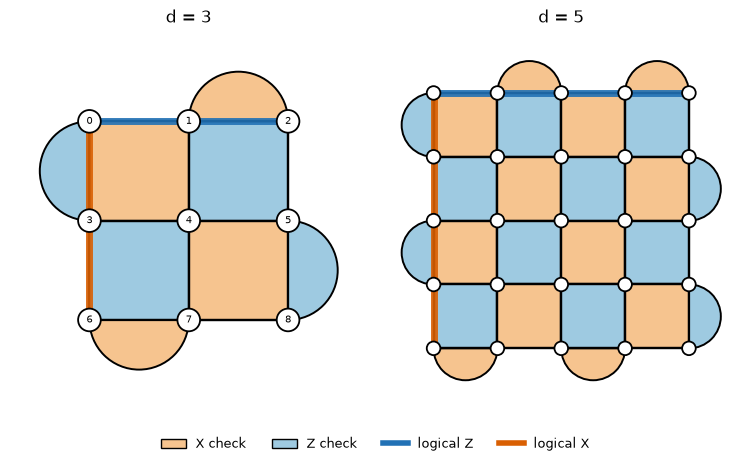

In [ ]:
for d in distances:
    code = codes.surface_code(d)
    n_x, n_z = mem.verify_code(code)
    dist = {(R, b): mem.code_distance(code, R, b) for R in (1, 3) for b in BASES}
    assert all(v == d for v in dist.values()), dist
    mismatches = 0
    for basis in BASES:
        circuit = mem.stim_circuit(code, 3, basis, p_2q=0.01)
        raw = circuit.compile_sampler().sample(500)
        dets, obs = circuit.compile_m2d_converter().convert(measurements=raw, separate_observables=True)
        raw = raw.astype(np.uint8)
        m = code.n_checks
        ours, logical = mem.detection_events(raw[:, :3 * m].reshape(-1, 3, m), raw[:, 3 * m:], code, basis)
        mismatches += int((ours != dets).any(axis=1).sum() + (logical != obs[:, 0]).sum())
    print(f"d = {d}: {code.n_data} data qubits, {n_x} X + {n_z} Z checks, stim distance {sorted(set(dist.values()))}, "
          f"detector round trip {mismatches} mismatches in {500 * len(BASES)} shots")

fig, axes = plt.subplots(1, len(distances), figsize=(3.8 * len(distances), 4.4), squeeze=False)
for ax, d in zip(axes[0], distances):
    ax, handles = plot_surface_code(codes.surface_code(d), ax=ax, labels=d <= 3)
    ax.set_title(f"d = {d}", pad=14)
fig.legend(handles=handles, loc="lower center", ncols=4, fontsize=9, frameon=False)
fig.tight_layout(rect=(0, 0.08, 1, 1))
plt.show()

The first round of the $d = 3$ circuit, before it is laid onto the chip: the `H` on the $X$ ancillas, four CNOT layers
(barriers keep the $Z$ ancillas from starting early), the measurements into `s0`, and the resets. Qubits 0-8 are
data, 9-16 the ancillas of the eight checks.

In [ ]:
print(mem.memory_circuit(codes.surface_code(3), rounds=1, basis="Z").draw(output="text", fold=160))

                                                                                                        ┌───┐                           ░     ┌─┐            »
 q_0: ────────────────────────────────────────────────────────────■─────────────────────────────────────┤ X ├───────────────────────────░─────┤M├────────────»
                                                                  │  ┌───┐     ┌───┐                    └─┬─┘                           ░     └╥┘┌─┐         »
 q_1: ────────────────────────────────────────────────────────────┼──┤ X ├─────┤ X ├──────────────────────┼────■────────────────────────░──────╫─┤M├─────────»
                                       ┌───┐                      │  └─┬─┘     └─┬─┘                      │    │                        ░      ║ └╥┘┌─┐      »
 q_2: ─────────────────────────────────┤ X ├───────■──────────────┼────┼─────────┼────────────────────────┼────┼────────────────────────░──────╫──╫─┤M├──────»
                                       └─┬─┘┌─

## 4. Patches

The patches to run: the given anchors, or the `N_BEST` placements with the lowest error budget per layer (CZ error of
every coupler, mid-circuit readout of every ancilla, two `sx` per qubit; `IBMBackend.error_budget`). Each patch gets its own
map, framed on its part of the chip: physical qubit numbers, data qubits in white, the ancillas of $X$ and $Z$ checks in
the colours of the code drawing, and the couplers each check uses.

d = 3: CodePatch(surface_d3, mcm, qubits 75..115), error budget 0.111 per round
d = 3: CodePatch(surface_d3, mcm, qubits 73..113), error budget 0.121 per round
d = 5: CodePatch(surface_d5, mcm, qubits 4..84), error budget 0.923 per round
d = 5: CodePatch(surface_d5, mcm, qubits 35..115), error budget 0.933 per round


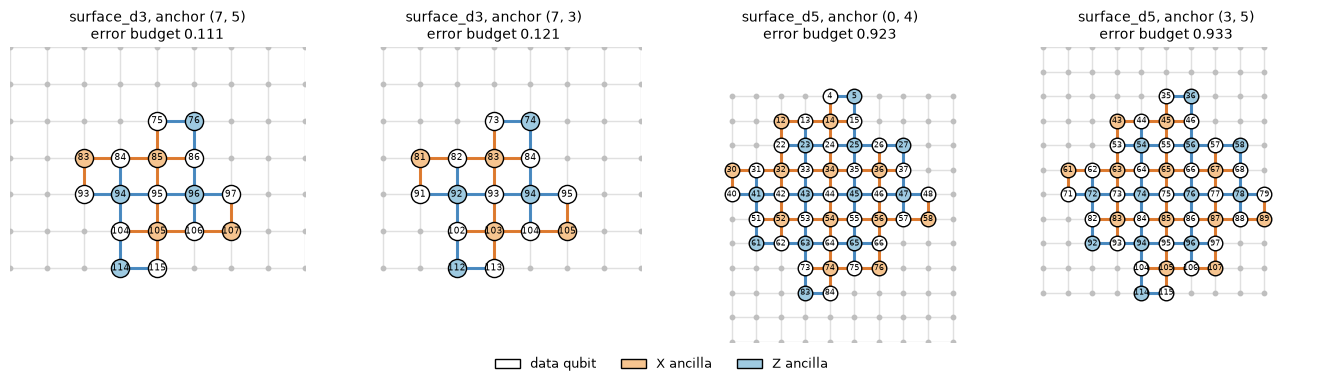

In [ ]:
patches = []
for d in distances:
    code = codes.surface_code(d)
    anchors = ANCHORS.get(d) if SUBMIT else None
    found = surface_code_placements(G, code, anchors=anchors)
    if anchors is None:
        score = (lambda patch: backend.error_budget(patch, cal)) if cal is not None else (lambda patch: 0.0)
        found = sorted(found, key=score)[:n_best]
    patches += found
    for patch in found:
        budget = f", error budget {backend.error_budget(patch, cal):.3f} per round" if cal is not None else ""
        print(f"d = {d}: {patch}{budget}")

from matplotlib.patches import Patch

ncols = min(len(patches), 4)
nrows = -(-len(patches) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(3.4 * ncols, 3.6 * nrows), squeeze=False)
for ax, patch in zip(axes.flat, patches):
    budget = f"\nerror budget {backend.error_budget(patch, cal):.3f}" if cal is not None else ""
    plot_patch_on_chip(G, coords, patch, ax=ax, title=f"{patch.code.name}, anchor {coords[patch.data_qubits[0]]}{budget}")
for ax in list(axes.flat)[len(patches):]:
    ax.axis("off")
fig.legend(handles=[Patch(facecolor="white", edgecolor="black", label="data qubit"),
                    Patch(facecolor=CHECK_COLOURS["X"], edgecolor="black", label="X ancilla"),
                    Patch(facecolor=CHECK_COLOURS["Z"], edgecolor="black", label="Z ancilla")],
           loc="lower center", ncols=3, fontsize=9, frameon=False)
fig.tight_layout(rect=(0, 0.06, 1, 1))
plt.show()

## 5. Plan, then submit

One circuit per patch, basis and round count. On a device each circuit is transpiled onto its patch's own qubits and
refused if any gate would need a coupler outside the patch. A memory circuit has no conditional gates, only
measurements and resets, so the classical-control limit on feed-forward jobs does not apply and up to 100 circuits
go into one job. A manifest is written after every job.

In [ ]:
memory_plan = mem.plan(backend, patches, rounds=rounds, bases=BASES, shots=shots, p_2q_model=P_2Q_MODEL)
mem.print_plan(memory_plan)

Backend  : ibm_phoenix
Patches  : 4 (surface_d3, surface_d5)
Sweep    : rounds [1, 2, 3, 5, 7, 10], bases ['Z', 'X'], 4000 shots each
Circuits : 48
Estimate : 2.5 QPU s (gate and readout durations only; the wait between shots is not included)


In [ ]:
manifest_path = mem.submit(memory_plan, backend, manifest_dir=DATA / "manifests", noise_model=noise, seed=7)

  job 1: 48 circuits -> dalv30lr85ps73fc0oi0
manifest: data/manifests/ibm_phoenix/20260917_155616_ibm_phoenix_surface_code_memory.json


## 6. Harvest

Needs only the manifest. Unfinished jobs are reported and skipped. Every shot's raw bits are stored in
`data/results/<device>/surface_code/memory/`, next to the decoded logical error rate.

In [ ]:
manifests = sorted((DATA / "manifests" / backend.name).glob("*_surface_code_memory.json"), key=lambda p: p.name)
assert manifests, "no manifest yet - run the submit cell first"
manifest_path = manifests[-1]
print("harvesting", manifest_path.name)
saved = mem.harvest(manifest_path, backend, data_dir=DATA / "results")

harvesting 20260917_155616_ibm_phoenix_surface_code_memory.json
48 memory results written to data/results/ibm_phoenix/surface_code/memory/20260917_155616_ibm_phoenix_surface_code_memory.json


## 7. Results

Logical error rate against rounds for every patch and basis, decoded again from the stored shots, with the fit of
$P_L(R) = \tfrac{1}{2}[1 - A(1 - 2\varepsilon_L)^R]$ (lines) and its logical error per round $\varepsilon_L$ in the table. A logical qubit that is protected keeps $\varepsilon_L$ below the error of
a single physical qubit, and a larger distance lowers it further only below threshold.

                             patch  basis               R=1              R=2              R=3              R=5              R=7             R=10       eps_L per round
CodePatch(surface_d3, mcm, qubits 73..113)      Z   0.0075+-0.0014  0.0245+-0.0024  0.0465+-0.0033  0.0943+-0.0046  0.1298+-0.0053  0.1893+-0.0062   0.0211 +- 0.0025 (A = 1.000)
CodePatch(surface_d3, mcm, qubits 73..113)      X   0.0198+-0.0022  0.2018+-0.0063  0.2880+-0.0072  0.3723+-0.0076  0.4318+-0.0078  0.4713+-0.0079   0.1128 +- 0.0235 (A = 1.000)
CodePatch(surface_d3, mcm, qubits 75..115)      Z   0.0143+-0.0019  0.0432+-0.0032  0.0793+-0.0043  0.1515+-0.0057  0.2030+-0.0064  0.2647+-0.0070   0.0341 +- 0.0036 (A = 1.000)
CodePatch(surface_d3, mcm, qubits 75..115)      X   0.0155+-0.0020  0.0635+-0.0039  0.1303+-0.0053  0.1995+-0.0063  0.2705+-0.0070  0.3523+-0.0076   0.0503 +- 0.0064 (A = 1.000)
CodePatch(surface_d5, mcm, qubits 4..84)      Z   0.0152+-0.0019  0.0808+-0.0043  0.1497+-0.0056  0.2607+-0.0069  0.3365+

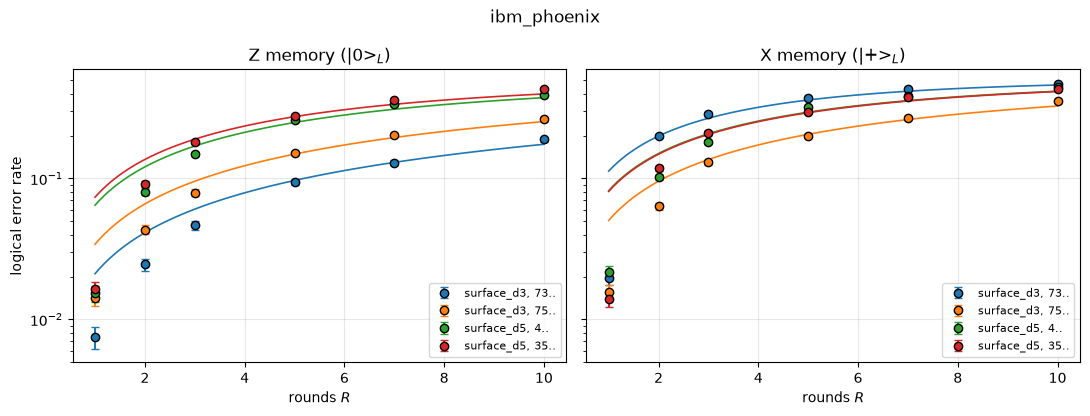

In [ ]:
results = mem.load_results(DATA / "results", backend.name, files={Path(saved).name})
fig, axes = plt.subplots(1, len(BASES), figsize=(5.5 * len(BASES), 4.2), sharey=True, squeeze=False)
print(f"{'patch':>34} {'basis':>6} " + "".join(f"{'R=' + str(R):>17}" for R in rounds) + f"{'eps_L per round':>22}")
for k, (patch, by_basis) in enumerate(sorted(results.items())):
    for ax, basis in zip(axes[0], BASES):
        if basis not in by_basis:
            continue
        rs = sorted(by_basis[basis])
        rate = np.array([by_basis[basis][R]["rate"] for R in rs])
        err = np.array([by_basis[basis][R]["err"] for R in rs])
        eps, eps_err, amplitude = mem.error_per_round(rs, rate)
        grid = np.linspace(min(rs), max(rs), 100)
        ax.errorbar(rs, rate, yerr=err, fmt="o", color=f"C{k}", mec="k", capsize=3, label=f"{patch.code.name}, {min(patch.qubits)}..")
        ax.plot(grid, (1 - amplitude * (1 - 2 * eps) ** grid) / 2, "-", color=f"C{k}", lw=1.2)
        print(f"{str(patch):>34} {basis:>6} " + "".join(f"  {r:.4f}+-{e:.4f}" for r, e in zip(rate, err))
              + f"   {eps:.4f} +- {eps_err:.4f} (A = {amplitude:.3f})")
for ax, basis in zip(axes[0], BASES):
    ax.set(xlabel="rounds $R$", title=f"{basis} memory ({'|0>' if basis == 'Z' else '|+>'}$_L$)", yscale="log")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
axes[0][0].set_ylabel("logical error rate")
fig.suptitle(backend.name)
fig.tight_layout()
fig.savefig(FIGURES / f"{backend.name}_surface_code_memory.pdf", bbox_inches="tight")
plt.show()